In [46]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [47]:
chessdf = pd.read_csv("/home/jsnnb/Chess_Opening_Predict/data/raw/games.csv")

In [48]:
print(chessdf)
#[20058 rows x 15 columns]

             id  rated    created_at  last_move_at  turns victory_status  \
0      TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime   
1      l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign   
2      mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate   
3      kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate   
4      9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate   
...         ...    ...           ...           ...    ...            ...   
20053  EfqH7VVH   True  1.499791e+12  1.499791e+12     24         resign   
20054  WSJDhbPl   True  1.499698e+12  1.499699e+12     82           mate   
20055  yrAas0Kj   True  1.499698e+12  1.499698e+12     35           mate   
20056  b0v4tRyF   True  1.499696e+12  1.499697e+12    109         resign   
20057  N8G2JHGG   True  1.499643e+12  1.499644e+12     78           mate   

      winner increment_code       white_id  white_rating            black_id  \
0      

In [49]:
chessdf.isnull().sum()
#Sem nulos

id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

In [50]:
chessdf.duplicated().sum()
#429 Duplicatas

429

In [51]:
chessdf = chessdf.drop_duplicates(keep="first")

In [52]:
chessdf.duplicated().sum()
#0 Duplicatas

0

In [53]:
chessdf.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [54]:
chessdf = chessdf.drop(columns=["id", "rated", "created_at", "last_move_at", "moves", "turns", "victory_status", "increment_code", "white_id", "black_id", "opening_name"])

In [55]:
print(chessdf)

      winner  white_rating  black_rating opening_eco  opening_ply
0      white          1500          1191         D10            5
1      black          1322          1261         B00            4
2      white          1496          1500         C20            3
3      white          1439          1454         D02            3
4      white          1523          1469         C41            5
...      ...           ...           ...         ...          ...
20053  white          1691          1220         A80            2
20054  black          1233          1196         A41            2
20055  white          1219          1286         D00            3
20056  white          1360          1227         B07            4
20057  black          1235          1339         D00            3

[19629 rows x 5 columns]


In [56]:
#Column Engineering

chessdf["white_rating_diff"] = chessdf["white_rating"] - chessdf["black_rating"]
chessdf.head(3)

,winner,white_rating,black_rating,opening_eco,opening_ply,white_rating_diff
0,white,1500,1191,D10,5,309
1,black,1322,1261,B00,4,61
2,white,1496,1500,C20,3,-4


In [57]:
chessdf = chessdf.drop(columns = ["white_rating", "black_rating"])
print(chessdf)

      winner opening_eco  opening_ply  white_rating_diff
0      white         D10            5                309
1      black         B00            4                 61
2      white         C20            3                 -4
3      white         D02            3                -15
4      white         C41            5                 54
...      ...         ...          ...                ...
20053  white         A80            2                471
20054  black         A41            2                 37
20055  white         D00            3                -67
20056  white         B07            4                133
20057  black         D00            3               -104

[19629 rows x 4 columns]


In [58]:
chessdf = chessdf[chessdf["winner"] != "draw"]

In [59]:
#Mapeamento de winner
chess_mapping: dict = {"white": 1, "black": 0}
chessdf["winner"] = chessdf["winner"].map(chess_mapping)

In [60]:
print(chessdf)
#[18711 rows x 4 columns]

       winner opening_eco  opening_ply  white_rating_diff
0           1         D10            5                309
1           0         B00            4                 61
2           1         C20            3                 -4
3           1         D02            3                -15
4           1         C41            5                 54
...       ...         ...          ...                ...
20053       1         A80            2                471
20054       0         A41            2                 37
20055       1         D00            3                -67
20056       1         B07            4                133
20057       0         D00            3               -104

[18711 rows x 4 columns]


In [61]:
#verificando proporcionalidade
chessdf['winner'].value_counts(normalize=True)

winner
1    0.523329
0    0.476671
Name: proportion, dtype: float64

In [62]:
#Verificando aberturas unicas
chessdf['opening_eco'].nunique()


359

In [63]:
#Verificando descrição da coluna criada
chessdf['white_rating_diff'].describe()

count    18711.000000
mean         7.631393
std        250.448400
min      -1605.000000
25%       -108.000000
50%          3.000000
75%        123.000000
max       1499.000000
Name: white_rating_diff, dtype: float64

In [64]:
#Verificando tipos
chessdf.dtypes

winner                int64
opening_eco          object
opening_ply           int64
white_rating_diff     int64
dtype: object

In [65]:
print(chessdf)

       winner opening_eco  opening_ply  white_rating_diff
0           1         D10            5                309
1           0         B00            4                 61
2           1         C20            3                 -4
3           1         D02            3                -15
4           1         C41            5                 54
...       ...         ...          ...                ...
20053       1         A80            2                471
20054       0         A41            2                 37
20055       1         D00            3                -67
20056       1         B07            4                133
20057       0         D00            3               -104

[18711 rows x 4 columns]


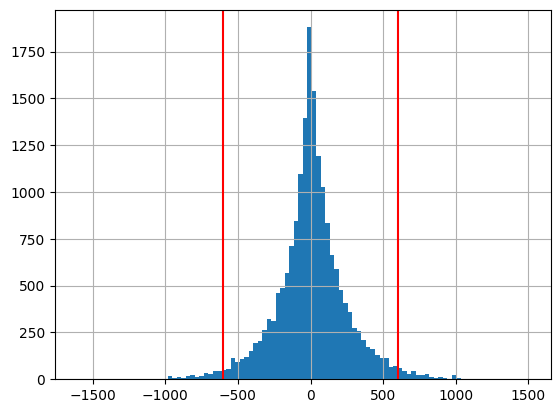

In [66]:
chessdf["white_rating_diff"].hist(bins=100)
plt.axvline(600, color="Red")
plt.axvline(-600, color="Red")
plt.show()

# Split train e test

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X = chessdf.drop(columns=["winner"])
y = chessdf["winner"]

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42, shuffle=True, stratify=y)